# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [67]:
#This data represents 17 separate direct marketing campaigns between May 2008 and November 2010.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [68]:
import pandas as pd
from sklearn.preprocessing import StandardScaler


In [69]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [70]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
df.head()



,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [72]:
#Business Objective:
#The objective is to develop a model that identifies which clients are most likely to subscribe to a term deposit, 
#using information about their demographics and past campaign outcomes.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [73]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# ---------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------
df = pd.read_csv('data/bank-additional-full.csv', sep=';')

# ---------------------------------------------------------
# 2. Drop duration (leaks target information)
# ---------------------------------------------------------
df = df.drop(columns=['duration'])

# ---------------------------------------------------------
# 3. Encode target variable
# ---------------------------------------------------------
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# ---------------------------------------------------------
# 4. Handle pdays (999 = never contacted)
# ---------------------------------------------------------
df['previously_contacted'] = (df['pdays'] != 999).astype(int)
df['pdays'] = df['pdays'].replace(999, None)

# ---------------------------------------------------------
# 5. Identify categorical and numeric columns
# ---------------------------------------------------------
categorical_cols = [
    'job','marital','education','default','housing','loan',
    'contact','month','day_of_week','poutcome'
]

numeric_cols = [
    'age','campaign','pdays','previous',
    'emp.var.rate','cons.price.idx','cons.conf.idx',
    'euribor3m','nr.employed'
]

# ---------------------------------------------------------
# 6. Ordinal encode categorical variables
# ---------------------------------------------------------
encoder = OrdinalEncoder()
df[categorical_cols] = encoder.fit_transform(df[categorical_cols])


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [74]:

# ---------------------------------------------------------
# 7. Train/test split (stratified)
# ---------------------------------------------------------
X = df.drop(columns=['y'])
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---------------------------------------------------------
# 8. Impute missing values
# ---------------------------------------------------------
num_imputer = SimpleImputer(strategy='median')
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

# (Categorical columns should not have NaN after encoding,
# but we include this for safety.)
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

# ---------------------------------------------------------
# 9. Scale numeric features (Logistic Regression, SVM, KNN)
# ---------------------------------------------------------
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# ---------------------------------------------------------
# Done — X_train, X_test, y_train, y_test are ready for modeling
# ---------------------------------------------------------

print("Preprocessing complete.")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Preprocessing complete.
Train shape: (32950, 20)
Test shape: (8238, 20)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [75]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

baselines = {
    "most_frequent": DummyClassifier(strategy="most_frequent"),
    "stratified": DummyClassifier(strategy="stratified"),
    "uniform": DummyClassifier(strategy="uniform"),
    "prior": DummyClassifier(strategy="prior")
}

results = {}

for name, model in baselines.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_proba)
    }

results


{'most_frequent': {'accuracy': 0.8873512988589464,
  'f1': 0.0,
  'auc': np.float64(0.5)},
 'stratified': {'accuracy': 0.8038358824957514,
  'f1': 0.11500547645125958,
  'auc': np.float64(0.5052484787018255)},
 'uniform': {'accuracy': 0.5029133284777859,
  'f1': 0.18669314796425024,
  'auc': np.float64(0.5)},
 'prior': {'accuracy': 0.8873512988589464, 'f1': 0.0, 'auc': np.float64(0.5)}}

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report

log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)

# Predict
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]


### Problem 9: Score the Model

What is the accuracy of your model?

In [77]:
accuracy_log_reg = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_log_reg)


Accuracy: 0.9007040543821316


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [78]:
import time
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings("ignore", message="Could not find the number of physical cores")

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(probability=True)   # needed for AUC
}

results = []

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Train Time (s)": end - start,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred)
    })


df_results = pd.DataFrame(results)
df_results


,Model,Train Time (s),Train Accuracy,Test Accuracy
0,Logistic Regression,0.150146,0.900182,0.900704
1,KNN,0.007846,0.910228,0.892571
2,Decision Tree,0.117778,0.995417,0.840374
3,SVM,111.040456,0.899909,0.900218


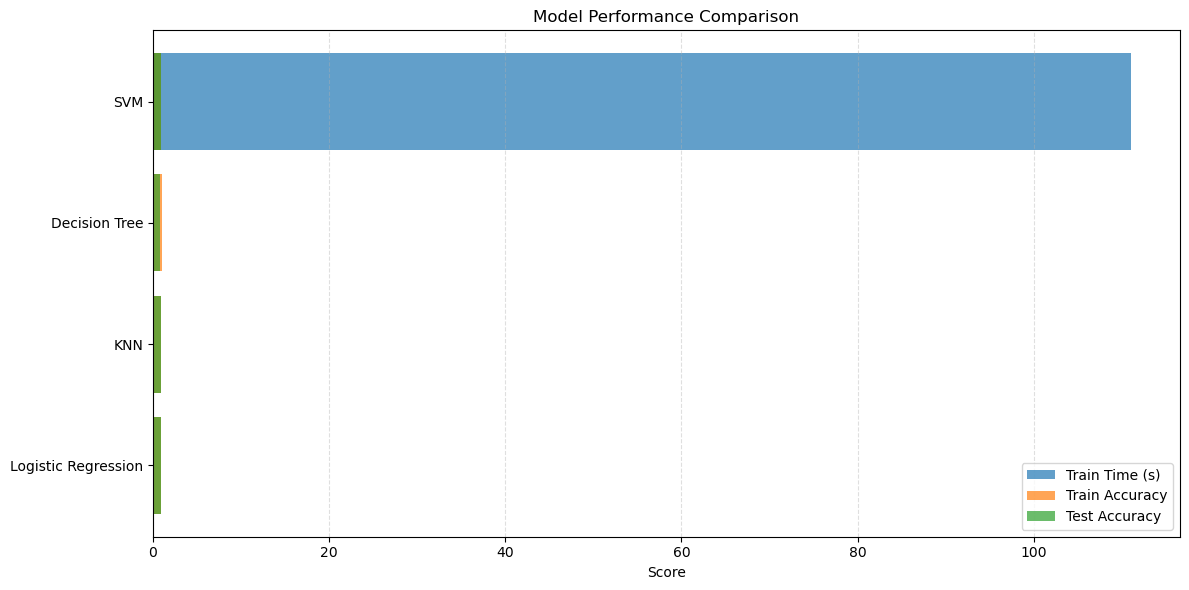

C:\Users\ramya\AppData\Local\Temp\ipykernel_7440\1059107214.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x="Model", y="Train Time (s)", palette="viridis")


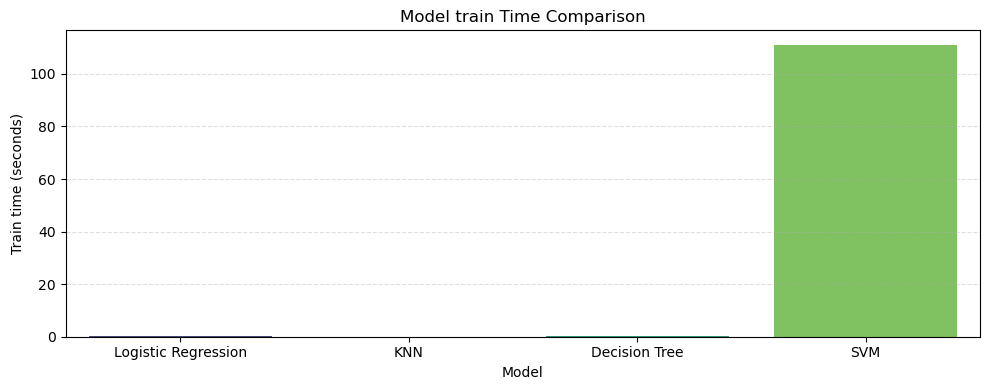

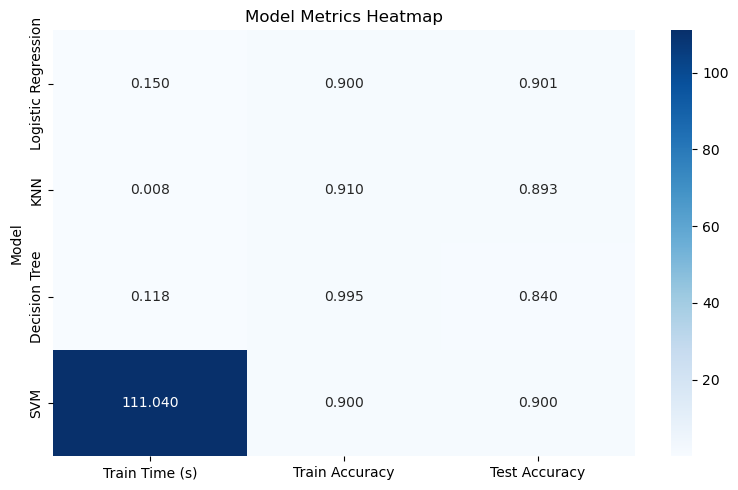

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df_results exists from your previous code

# -----------------------------
# 1. Horizontal Bar Chart for All Metrics
# -----------------------------
metrics = ["Train Time (s)", "Train Accuracy", "Test Accuracy"]

plt.figure(figsize=(12, 6))
for metric in metrics:
    plt.barh(df_results["Model"], df_results[metric], label=metric, alpha=0.7)

plt.xlabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# -----------------------------
# 2. Fit Time Comparison
# -----------------------------
plt.figure(figsize=(10, 4))
sns.barplot(data=df_results, x="Model", y="Train Time (s)", palette="viridis")
plt.title("Model train Time Comparison")
plt.ylabel("Train time (seconds)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# -----------------------------
# 3. Heatmap of Metrics
# -----------------------------
plt.figure(figsize=(8, 5))
sns.heatmap(
    df_results.set_index("Model")[metrics],
    annot=True,
    cmap="Blues",
    fmt=".3f"
)
plt.title("Model Metrics Heatmap")
plt.tight_layout()
plt.show()


In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(probability=True)
}

results = []

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Probabilities for AUC
    if hasattr(model, "predict_proba"):
        test_proba = model.predict_proba(X_test)[:, 1]
    else:
        test_proba = model.decision_function(X_test)
    
    results.append({
        "Model": name,
        "Train Time (s)": round(end - start, 4),
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Precision": precision_score(y_test, test_pred),
        "Recall": recall_score(y_test, test_pred),
        "F1 Score": f1_score(y_test, test_pred),
        "AUC": roc_auc_score(y_test, test_proba)
    })

df_results = pd.DataFrame(results)
df_results


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

knn = KNeighborsClassifier()

grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

dt = DecisionTreeClassifier()

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)


In [ ]:
from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

lr = LogisticRegression(max_iter=500)

grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)


In [ ]:
from sklearn.svm import SVC

param_grid_svm = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.1, 0.01]
}

svm = SVC(probability=True)

grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)


In [ ]:
results = {
    "Model": ["KNN", "Decision Tree", "Logistic Regression", "SVM"],
    "Best AUC": [
        grid_knn.best_score_,
        grid_dt.best_score_,
        grid_lr.best_score_,
        grid_svm.best_score_
    ],
    "Best Params": [
        grid_knn.best_params_,
        grid_dt.best_params_,
        grid_lr.best_params_,
        grid_svm.best_params_
    ]
}

pd.DataFrame(results)


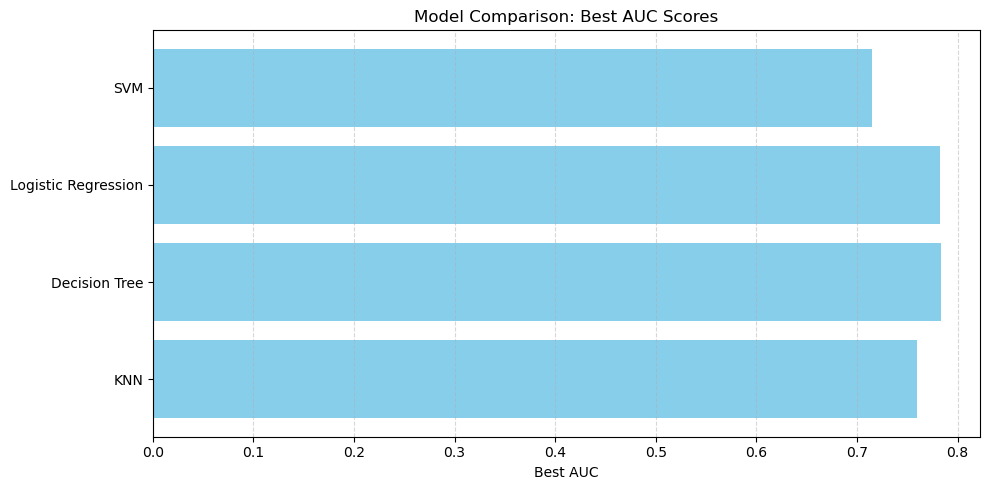

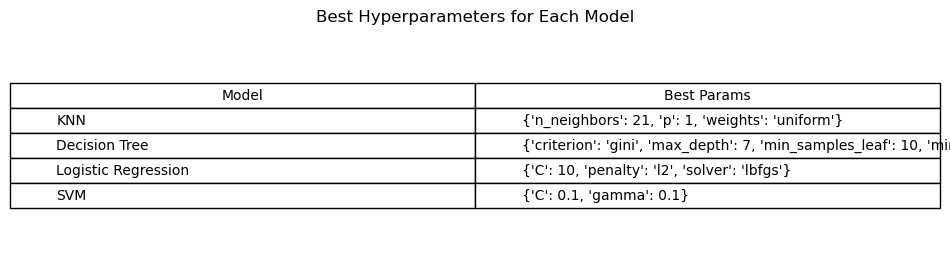

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

# Your results dictionary
results = {
    "Model": ["KNN", "Decision Tree", "Logistic Regression", "SVM"],
    "Best AUC": [
        grid_knn.best_score_,
        grid_dt.best_score_,
        grid_lr.best_score_,
        grid_svm.best_score_
    ],
    "Best Params": [
        grid_knn.best_params_,
        grid_dt.best_params_,
        grid_lr.best_params_,
        grid_svm.best_params_
    ]
}

df = pd.DataFrame(results)

# -----------------------------
# 1. Horizontal Bar Chart (Best AUC)
# -----------------------------
plt.figure(figsize=(10, 5))
plt.barh(df["Model"], df["Best AUC"], color="skyblue")
plt.xlabel("Best AUC")
plt.title("Model Comparison: Best AUC Scores")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# -----------------------------
# 2. Table of Best Params
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis("off")
table_data = [[m, str(p)] for m, p in zip(df["Model"], df["Best Params"])]
table = ax.table(
    cellText=table_data,
    colLabels=["Model", "Best Params"],
    loc="center",
    cellLoc="left"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
plt.title("Best Hyperparameters for Each Model")
plt.show()


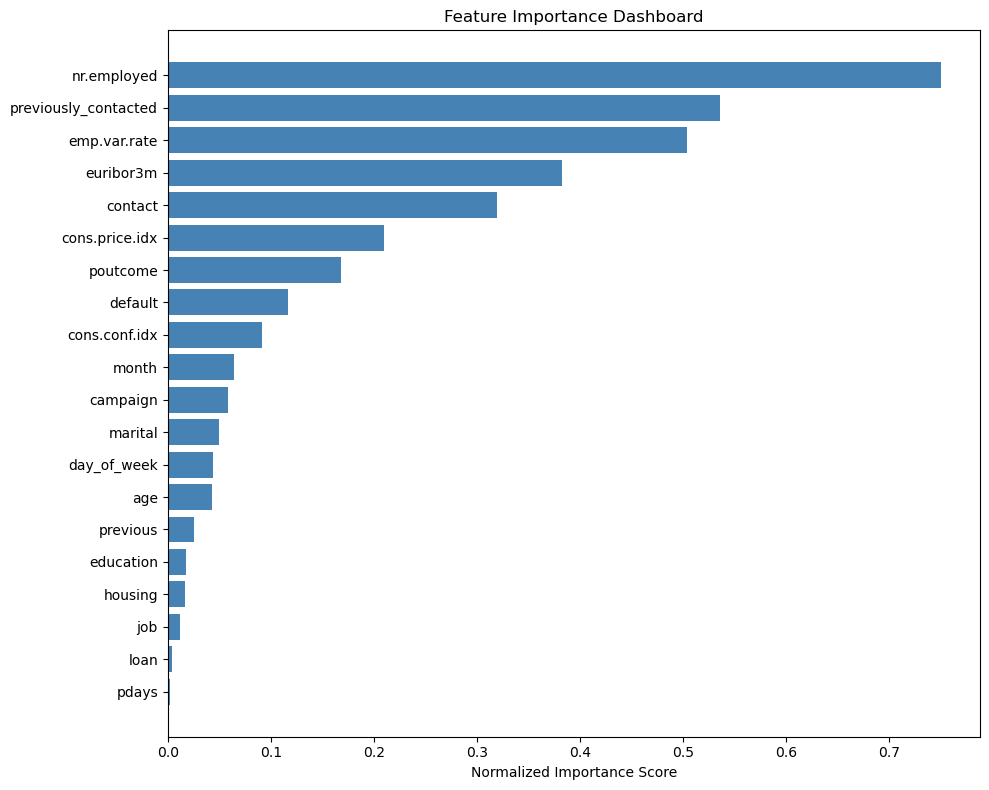

,Feature,Decision Tree Importance,Logistic Regression Coef,Average Importance
18,nr.employed,1.000000,0.501163,0.750581
19,previously_contacted,0.199352,0.872047,0.535700
14,emp.var.rate,0.008214,1.000000,0.504107
17,euribor3m,0.114811,0.650373,0.382592
7,contact,0.032100,0.606846,0.319473
15,cons.price.idx,0.022348,0.397967,0.210158
13,poutcome,0.024871,0.310485,0.167678
4,default,0.000000,0.232894,0.116447
16,cons.conf.idx,0.101858,0.080366,0.091112
8,month,0.055694,0.072407,0.064050


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Extract Feature Importances ---

# Decision Tree
dt_model = grid_dt.best_estimator_
dt_importance = dt_model.feature_importances_

# Logistic Regression
lr_model = grid_lr.best_estimator_
lr_coef = np.abs(lr_model.coef_[0])  # absolute values for comparison

# Combine into a single DataFrame
feat_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Decision Tree Importance": dt_importance,
    "Logistic Regression Coef": lr_coef
})

# Normalize each column for comparison
for col in ["Decision Tree Importance", "Logistic Regression Coef"]:
    feat_df[col] = feat_df[col] / feat_df[col].max()

# Average importance across models
feat_df["Average Importance"] = feat_df[
    ["Decision Tree Importance", "Logistic Regression Coef"]
].mean(axis=1)

# Sort by importance
feat_df_sorted = feat_df.sort_values("Average Importance", ascending=False)

# --- Plot Dashboard ---
plt.figure(figsize=(10, 8))
plt.barh(feat_df_sorted["Feature"], feat_df_sorted["Average Importance"], color="steelblue")
plt.gca().invert_yaxis()
plt.title("Feature Importance Dashboard")
plt.xlabel("Normalized Importance Score")
plt.tight_layout()
plt.show()

# Print top features
feat_df_sorted.head(10)

##### Questions